# Biotech/Pharma Stock Volatility

I read recently, in the book *Inside the Black Box* by Rishi Narang, that quantitative 
researchers typically are not interested in biotechnology stocks. The specific
passage was: 

>  Third, quants tend to prefer instruments that behave in a
manner conducive to being predicted by systematic models. Returning to
the example of biotechnology stocks, some quants exclude them because
they are subject to sudden, violent price changes based on events such as
government approval or rejection of their latest drug.

The goal of this project is to quantify and visualise whether or not this is actually 
true

In [1]:
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

## Choice of Stocks

Our goal is to illustrate sudden prices moves, primarily from approval/rejection events.
Therefore, it would be useful to focus on candidates that: 
- are small, because larger companies (typically) have a more diversified set of pipelines/projects,
- have a history of these sources (just easier to identify this way). 

Note/disclaimer: for the second point I did use an LLM to help me generate some 
tickers, as I am not particularly familiar with the history beyond some obvious
ones (e.g. BioNTech with the COVID-19 vaccine). Obviously it would be more thorough
to go through primary sources released by e.g. the FDA, but this is a side project 
so rigour is important but not paramount. :^)

In [2]:
TICKERS = {
    # "boring" big pharma contrast
    "PFE": "Pfizer",
    # larger company, but still saw big swings during the pandemic
    "MRNA": "Moderna",
    # for the most part stable, as it is a big pharma company, but has Alzeimer edge case
    "LLY": "Eli Lilly",
    # COVID
    "BNTX": "BioNTech",
    # DMD gene therapy
    "SRPT": "Sarepta",
    # Aduhelm Alzeimer's controversy 2023
    "BIIB": "Biogen",
    # late covid vaccine, extreme binary event
    "NVAX": "Novavax",
    # resmetiron NASH approval 2024
    "MDGL": "Madrigal Pharmaceuticals",
    # ETF baseline: is even the basket volatile?
    "XBI": "SPDR S&P Biotech ETF",

    # "REGN": "Regeneron",
    # "VRTX": "Vertex",
    # "ALNY": "Alnylam",
}

## Plotting Stock Prices

Let's start by simply visualising the stock prices for each of these chosen companies.

In [3]:
def fetch_prices(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    """Use yfinance IPA to fetch the daily-adjusted close prices for `tickers`
    between the dates [start, end)

    Return: Pandas DataFrame indexed by date, one column per ticker
    """
    raw = yf.download(
        tickers, start=start, end=end, auto_adjust=True, progress=False, group_by='column'
    )
    if raw.empty:
        raise ValueError(f"yfinance returned empty data for {tickers} for {start} to {end}")

    close = raw["Close"]
    if isinstance(close, pd.Series):
        close = close.to_frame(name=tickers[0])
    return close.dropna(how="all")

DATE_START = "2018-01-01" # pre-pandemic baseline
DATE_END = "2026-06-01" # roughly current date

In [4]:
# making sure it works as expected...
prices = fetch_prices(list(TICKERS.keys()), DATE_START, DATE_END)
prices

Ticker,BIIB,BNTX,LLY,MDGL,MRNA,NVAX,PFE,SRPT,XBI
Date,,,,,,,,,
2018-01-02,334.170013,NaN,74.897758,97.419998,NaN,26.000000,23.443445,58.250000,86.262932
2018-01-03,339.850006,NaN,75.304649,98.910004,NaN,27.000000,23.617142,58.549999,87.410339
2018-01-04,339.989990,NaN,75.640724,97.879997,NaN,26.400000,23.668608,57.810001,86.401405
2018-01-05,342.489990,NaN,76.569450,96.529999,NaN,25.799999,23.713646,54.869999,86.094765
2018-01-08,329.649994,NaN,76.180260,93.349998,NaN,27.000000,23.449873,54.020000,84.383553
...,...,...,...,...,...,...,...,...,...
2026-05-22,193.759995,92.139999,1065.000000,517.260010,46.880001,9.210000,25.900000,16.799999,131.530884
2026-05-26,193.080002,92.250000,1064.739990,524.280029,47.029999,10.460000,25.850000,16.670000,133.219238
2026-05-27,196.970001,93.000000,1082.920044,527.669983,47.610001,11.090000,26.209999,16.680000,134.318146


Ticker              LLY       NVAX
Date                              
2018-01-02    74.897758  26.000000
2018-01-03    75.304649  27.000000
2018-01-04    75.640724  26.400000
2018-01-05    76.569450  25.799999
2018-01-08    76.180260  27.000000
...                 ...        ...
2026-05-22  1065.000000   9.210000
2026-05-26  1064.739990  10.460000
2026-05-27  1082.920044  11.090000
2026-05-28  1126.800049  10.320000
2026-05-29  1105.000000  10.970000

[2113 rows x 2 columns]


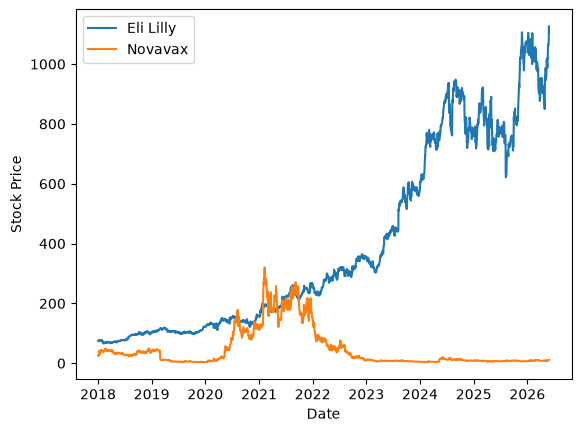

In [5]:
# will likely need to normalise stock prices somehow; see LLY and NVAX as examples
print(prices[['LLY', 'NVAX']])
# fig = go.Figure()
# matplotlib is easier to work with but for putting stuff on website, plotly is nicer
plt.plot(prices['LLY'], label=TICKERS['LLY'])
plt.plot(prices['NVAX'], label=TICKERS['NVAX'])
plt.legend()
plt.ylabel("Stock Price")
plt.xlabel("Date")
plt.gcf().savefig("assets/plots/lly_nvax.png", dpi=200, bbox_inches="tight")


In [6]:
# Normalize to 100 at first valid date per ticker so different price scales are comparable
# and easier to read and interpret
normalized = prices.div(prices.bfill().iloc[0]) * 100
# normalized = prices

fig_price = go.Figure()
for ticker, name in TICKERS.items():
    if ticker not in normalized.columns:
        continue
    fig_price.add_trace(go.Scatter(
        x=normalized.index,
        y=normalized[ticker],
        name=name,
        mode="lines",
        hovertemplate="%{x|%Y-%m-%d}<br>%{y:.1f}<extra>" + name + "</extra>",
    ))

fig_price.update_layout(
    title="Biotech/Pharma Normalized Price (base 100 = 2018-01-02)",
    xaxis_title="Date",
    yaxis_title="Normalized Price",
    hovermode="x unified",
    legend=dict(orientation="v"),
)
# first plotly figure on the page: bundle plotly.js itself (via cdn)
fig_price.write_html(
    "assets/plots/price_basic.html",
    include_plotlyjs="cdn",
    full_html=False,
    config={"responsive": True},
)
fig_price.show()


## Events

Now let's add relevant events to the plots and see what happens. Reusing a lot of code here, though of course in practice these should be put in modules/files.

In [7]:
# https://www.fda.gov/news-events/fda-newsroom/press-announcements
# this can likely be automated with an API and/or an LLM to pull and process news articles
# disclaimer: I used an LLM (not a local one) to get most of these press releases,
#   though I did verify them, and in same cases correct them


# It is much easier to find approvals than it is to find rejections (not typically published)
# so I am primarily tracking those
EVENTS = {
    # TODO
    "MRNA": [
    # https://www.fda.gov/vaccines-blood-biologics/spikevax
    ("2022-01-31", "Spikevax Approval"),
    # https://www.fda.gov/media/144434/download
    ("2020-12-17", "Moderna COVID Approval")
        ],
    "PFE": [
        # https://www.fda.gov/news-events/press-announcements/fda-approves-first-covid-19-vaccine
        ("2021-08-23", "COVID-19 Vaccine"),
        # https://www.fda.gov/news-events/press-announcements/coronavirus-covid-19-update-fda-authorizes-first-oral-antiviral-treatment-covid-19
        ("2021-12-22", "COVID-19 Oral Antiviral") # paxlovid
        ],
    "BIIB": [
        # https://www.accessdata.fda.gov/drugsatfda_docs/appletter/2021/761178Orig1s000ltr.pdf
        ("2021-06-07", "Aduhelm Acc. Approval"),
        # https://www.fda.gov/drugs/drug-trials-snapshots/drug-trials-snapshots-leqembi
        ("2023-01-06", "Leqembi Acc. Approval"),
        # https://www.fda.gov/drugs/drug-trials-snapshots/drug-trials-snapshots-leqembi
        ("2023-07-06", "Leqembi Full Approval")
        ],
    "BNTX": [
        # https://www.fda.gov/news-events/press-announcements/fda-approves-first-covid-19-vaccine
        ("2021-08-23", "COVID-19 Vaccine"),
        # https://pmc.ncbi.nlm.nih.gov/articles/PMC7938284/
        ("2020-12-11", "COVID-19 Emergency Approval") # EU and UK limited approval
        ],
    "LLY": [
        # https://www.fda.gov/drugs/news-events-human-drugs/fda-approves-treatment-adults-alzheimers-disease
        ("2024-07-02", "Alzheimer's Treatment")
        ],
    "MDGL": [
        # https://www.fda.gov/news-events/press-announcements/fda-approves-first-treatment-patients-liver-scarring-due-fatty-liver-disease
        ("2024-03-14", "Rezdiffra Approval")
        ],
    "NVAX": [
        # https://www.fda.gov/vaccines-blood-biologics/coronavirus-covid-19-cber-regulated-biologics/novavax-covid-19-vaccine-adjuvanted
        ("2022-07-13", "COVID-19 Emergency Approval")
        ],
    "SRPT": [
        # https://www.fda.gov/media/169715/download
        ("2023-06-22", "DMD Gene Therapy"),
        # https://www.fda.gov/news-events/press-announcements/fda-expands-approval-gene-therapy-patients-duchenne-muscular-dystrophy
        ("2024-06-20", "DMD Therapy Expanded Approval")
        ],
    # XBI is a collection, so no specific events
    "XBI": [],
}

In [8]:
import plotly.colors

palette = plotly.colors.qualitative.Plotly
COLORS = {ticker: palette[i % len(palette)] for i, ticker in enumerate(TICKERS)}

normalized = prices.div(prices.bfill().iloc[0]) * 100
y_min = normalized.min().min()
y_max = normalized.max().max()

fig_price_events = go.Figure()

for ticker, name in TICKERS.items():
    if ticker not in normalized.columns:
        continue
    fig_price_events.add_trace(go.Scatter(
        x=normalized.index,
        y=normalized[ticker],
        name=name,
        mode="lines",
        line=dict(color=COLORS[ticker]),
        legendgroup=ticker,
        hovertemplate="%{x|%Y-%m-%d}<br>%{y:.1f}<extra>" + name + "</extra>",
    ))

for ticker, events in EVENTS.items():
    if ticker not in normalized.columns or not events:
        continue
    # bundle all vertical lines into one trace using None-separated segments
    x_vlines, y_vlines = [], []
    dates, ys, labels = [], [], []
    for date, desc in events:
        idx = normalized.index.searchsorted(date)
        if idx >= len(normalized):
            continue
        actual_date = normalized.index[idx]
        x_vlines += [actual_date, actual_date, None]
        y_vlines += [y_min, y_max, None]
        dates.append(actual_date)
        ys.append(normalized.loc[actual_date, ticker])
        labels.append(desc)
    fig_price_events.add_trace(go.Scatter(
        x=x_vlines,
        y=y_vlines,
        mode="lines",
        line=dict(dash="dot", color=COLORS[ticker], width=1.5),
        opacity=0.6,
        legendgroup=ticker,
        showlegend=False,
        hoverinfo="skip",
    ))
    fig_price_events.add_trace(go.Scatter(
        x=dates,
        y=ys,
        mode="markers",
        marker=dict(symbol="diamond", size=9, color=COLORS[ticker],
                    line=dict(width=1, color="white")),
        customdata=labels,
        hovertemplate="<b>%{customdata}</b><br>%{x|%Y-%m-%d}<extra></extra>",
        legendgroup=ticker,
        showlegend=False,
    ))

fig_price_events.update_layout(
    title="Biotech/Pharma Normalized Price (base 100 = 2018-01-02)",
    xaxis_title="Date",
    yaxis_title="Normalized Price",
    hovermode="x unified",
    legend=dict(orientation="v", groupclick="togglegroup"),
)
# plotly.js already loaded by fig_price's export above; don't bundle it again
fig_price_events.write_html(
    "assets/plots/price_events.html",
    include_plotlyjs=False,
    full_html=False,
    config={"responsive": True},
)
fig_price_events.show()

## Cumulative Abnormal Returns Analysis

The events in the previous plots are quite interesting. Some observations: 
- Events don't necessarily align with peaks, but they typically are shortly *after* a peak. This makes sense, as markets tend to anticipate and PDUFA dates are public months in advance. Stocks tend to run up before the approval then sell on the news. 
- Some peaks are unrelated. Also makes sense: I didn't capture every event, there is inherent stochasticity, and of course there are many major events not related to drug approvals. Some obvious ones are lockdowns, stimulus, risk sentiments. 

A single event on a regular price chart is therefore not enough. Instead let's consider the 
*cumulative abnormal return* (CAR) for each stock. CAR is intended to show whether an event caused
a statistically unusual move, and when relative to announcement. 

Define an **event window** $[t_0 - N,\, t_0 + N]$ of $N$ trading days around the event date $t_0$, and an **estimation window** of $W$ trading days ending a short gap before $t_0$. 
<!-- Here we use $N = 5$ and $W = 200$, with a 10-day gap. -->

To separate a stock's normal behaviour from any event-driven move, we fit a **market model** using ordinary least squares (OLS) over the estimation window $W$:

$$R_{i,t} = \alpha_i + \beta_i R_{m,t} + \varepsilon_{i,t}$$

where $R_{i,t} = \frac{S_t - S_{t-1}}{S_{t-1}}$ (where $S_t$ is the stock price at time $t$) is the daily return of stock $i$, $R_{m,t}$ is the daily return of the benchmark (XBI), and $\hat\alpha_i$, $\hat\beta_i$ are estimated from the estimation window. Intuitively, $\hat\beta_i$ captures how much the stock typically moves with the broader biotech sector.

The **abnormal return** on each day of the event window is simply the difference between what actually happened and what our OLS predicted:

$$AR_{i,t} = R_{i,t} - (\hat\alpha_i + \hat\beta_i\, R_{m,t})$$

Finally, the **cumulative abnormal return** (CAR) is the running sum of these residuals across the event window:

$$\text{CAR}_i(t_1, t_2) = \sum_{t=t_1}^{t_2} AR_{i,t}$$

To understand this, for example, a large positive CAR at day $+5$ means the stock earned significantly more than the market model predicted over those 10 days, implying an event-driven move. CAR also gives some intuition for how long the market took to respond to an event, so to speak, with time $t-t_0$. 

In [9]:
import statsmodels.api as sm

def get_model(prices: pd.DataFrame, ticker: str, event_date,
              est_window: int = 200, est_gap: int = 10):
    """Fit market model (OLS) over estimation window for a single ticker.

    Estimation window: [event_date - est_gap - est_window, event_date - est_gap)
    The gap avoids look-ahead bias (estimation window never overlaps event window).
    """
    # pct_change computes $(S_t - S_{t-1}) / S_{t-1}$,
    # i.e. it takes our stock prices and gives us daily returns
    returns = prices.pct_change().dropna(how="all")

    event_idx = returns.index.searchsorted(pd.Timestamp(event_date))
    end_idx = event_idx - est_gap
    start_idx = end_idx - est_window

    if start_idx < 0:
        raise ValueError(f"Not enough history for {ticker} before {event_date}")

    est = returns.iloc[start_idx:end_idx]
    X = sm.add_constant(est["XBI"])
    return sm.OLS(est[ticker], X).fit()


def compute_car(prices: pd.DataFrame, ticker: str, event_date,
                event_window: int = 5, est_window: int = 200, est_gap: int = 10):
    """Compute daily AR and CAR for a single (ticker, event) pair.

    event_window N -> days [-N, +N] around event_date (2N+1 days total).
    Returns DataFrame: day_offset, date, R_actual, R_predicted, AR, CAR, resid_std
    """
    returns = prices.pct_change().dropna(how="all")
    model = get_model(prices, ticker, event_date, est_window, est_gap)
    alpha, beta = model.params

    event_idx = returns.index.searchsorted(pd.Timestamp(event_date))
    win_start = event_idx - event_window
    win_end = event_idx + event_window + 1

    if win_start < 0 or win_end > len(returns):
        raise ValueError(f"Event window out of bounds for {ticker} at {event_date}")

    window = returns.iloc[win_start:win_end]
    r_actual = window[ticker]
    r_predicted = alpha + beta * window["XBI"]
    ar = r_actual - r_predicted

    return pd.DataFrame({
        "day_offset": range(-event_window, event_window + 1),
        "date": window.index,
        "R_actual": r_actual.values,
        "R_predicted": r_predicted.values,
        "AR": ar.values,
        "CAR": ar.cumsum().values,
        "resid_std": model.mse_resid ** 0.5,
    })

In [10]:
EST_WINDOW = 200
EST_GAP = 10
EVENT_WINDOW = 5

records = []
for ticker, events in EVENTS.items():
    if ticker == "XBI" or not events:
        continue
    for event_date, desc in events:
        try:
            car_df = compute_car(prices, ticker, event_date, EVENT_WINDOW, EST_WINDOW, EST_GAP)
            car_df["ticker"] = ticker
            car_df["event_date"] = event_date
            car_df["event_desc"] = desc
            records.append(car_df)
        except ValueError as e:
            print(f"Skipping {ticker} {event_date}: {e}")

all_car = pd.concat(records, ignore_index=True)
all_car

,day_offset,date,R_actual,R_predicted,AR,CAR,resid_std,ticker,event_date,event_desc
0,-5,2022-01-24,-0.017305,0.020840,-0.038145,-0.038145,0.049433,MRNA,2022-01-31,Spikevax Approval
1,-4,2022-01-25,-0.030261,-0.000860,-0.029401,-0.067546,0.049433,MRNA,2022-01-31,Spikevax Approval
2,-3,2022-01-26,0.015865,-0.009016,0.024881,-0.042665,0.049433,MRNA,2022-01-31,Spikevax Approval
3,-2,2022-01-27,-0.040914,-0.027166,-0.013748,-0.056413,0.049433,MRNA,2022-01-31,Spikevax Approval
4,-1,2022-01-28,0.073005,0.029790,0.043215,-0.013198,0.049433,MRNA,2022-01-31,Spikevax Approval
...,...,...,...,...,...,...,...,...,...,...
149,1,2024-06-21,0.301377,0.016793,0.284583,0.317902,0.036685,SRPT,2024-06-20,DMD Therapy Expanded Approval
150,2,2024-06-24,0.019475,0.009956,0.009519,0.327421,0.036685,SRPT,2024-06-20,DMD Therapy Expanded Approval
151,3,2024-06-25,-0.035337,-0.003486,-0.031852,0.295569,0.036685,SRPT,2024-06-20,DMD Therapy Expanded Approval
152,4,2024-06-26,-0.007276,-0.004957,-0.002319,0.293251,0.036685,SRPT,2024-06-20,DMD Therapy Expanded Approval


In [11]:
MARKERS = ["circle", "triangle-up", "triangle-down", "square", "diamond", "pentagon"]

fig_car = go.Figure()

# track which ticker each trace belongs to for the dropdown
trace_tickers = []

for ticker in TICKERS:
    if ticker == "XBI":
        continue
    subset = all_car[all_car["ticker"] == ticker]
    if subset.empty:
        continue

    for event_idx, ((event_date, event_desc), grp) in enumerate(
        subset.groupby(["event_date", "event_desc"])
    ):
        grp = grp.sort_values("day_offset")
        label = f"{TICKERS[ticker]}: {event_desc}"
        marker_symbol = MARKERS[event_idx % len(MARKERS)]

        # CAR line (as percentage)
        fig_car.add_trace(go.Scatter(
            x=grp["day_offset"],
            y=grp["CAR"] * 100,
            mode="lines+markers",
            name=label,
            line=dict(color=COLORS[ticker]),
            marker=dict(symbol=marker_symbol, size=7),
            legendgroup=ticker,
            hovertemplate="Day %{x}<br>CAR: %{y:.2f}%<extra>" + label + "</extra>",
        ))
        trace_tickers.append(ticker)

        # confidence band: Var(CAR up to day k) = k * σ²_ε
        # (MacKinlay 1997: AR_t i.i.d. under H0, so variances add)
        # https://www.jstor.org/stable/2729691?seq=12
        k = (grp["day_offset"] - grp["day_offset"].iloc[0] + 1).values
        sigma = grp["resid_std"].iloc[0]
        std_car = sigma * k ** 0.5
        upper = grp["CAR"].values * 100 + std_car * 100
        lower = grp["CAR"].values * 100 - std_car * 100
        offsets = grp["day_offset"].tolist()

        fig_car.add_trace(go.Scatter(
            x=offsets + offsets[::-1],
            y=upper.tolist() + lower.tolist()[::-1],
            fill="toself",
            fillcolor=COLORS[ticker],
            opacity=0.12,
            line=dict(width=0),
            legendgroup=ticker,
            showlegend=False,
            hoverinfo="skip",
        ))
        trace_tickers.append(ticker)

# zero baseline and event-day marker
fig_car.add_hline(y=0, line=dict(color="grey", width=1, dash="dash"))
fig_car.add_vline(x=0, line=dict(color="grey", width=1, dash="dot"),
              annotation_text="event", annotation_position="top right")

# dropdown to filter by ticker (pure client-side restyle, no server needed)
buttons = [dict(label="All", method="restyle",
                args=[{"visible": [True] * len(trace_tickers)}])]
for ticker in TICKERS:
    if ticker == "XBI":
        continue
    visible = [t == ticker for t in trace_tickers]
    if not any(visible):
        continue
    buttons.append(dict(
        label=TICKERS[ticker],
        method="restyle",
        args=[{"visible": visible}],
    ))

fig_car.update_layout(
    title=(
        f"Cumulative Abnormal Return (CAR) Around FDA Events<br>"
        f"<sup>Event window ±{EVENT_WINDOW} days | Estimation window {EST_WINDOW} days"
        f" | Benchmark: XBI | Shaded: ±σ</sup>"
    ),
    # margin=dict(t=120),
    xaxis_title="Trading Days Relative to Event",
    yaxis_title="CAR (%)",
    hovermode="closest",
    legend=dict(orientation="v", groupclick="togglegroup"),
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=1.4,
        xanchor="right",
        y=1.2,
        yanchor="top",
    )],
)
# plotly.js already loaded by fig_price's export above; don't bundle it again
fig_car.write_html(
    "assets/plots/car.html",
    include_plotlyjs=False,
    full_html=False,
    config={"responsive": True},
)
fig_car.show()

## Outlook

We have plotted the stock prices for a handful of companies, of varying size, and hard-coded in some major drug approval dates to see how the market reacted. We have also plotted the CAR for these events, which made it clearer for some of the stocks/events. However, there are certainly more ways to study this:
- Perhaps the simplest would be to try a handful of different estimation windows, event windows, and gaps. Event windows should be kept tight to avoid capturing irrelevant events, and gaps in this case may want to be made larger since these FDA approval announcements are typically anounced later than the market appears to react. 
- We may want to use automated event finding, and include rejections in addition to approvals: perhaps there is a public API out there which can be sifted. 
- We need a better baseline. One way to validate the significance is to build an empirical null distribution. For example, draw $K$ random "events" dates from a ticker's price history (outside event date estimate windows). Compute CAR for each such "event" in the same way and use this collection of as a baseline. A real event's CAR at some day is significant if it exceeds some percentile relative to this empirical distribution. This null distribution would effectively give us "what CAR looks like when nothing happens". 
- The model prediction, while based on an actual academic article, is somewhat naive and could probably be improved. I guess there is a more sophisticated approach than simple OLS (maybe ridge regression?), or some way to reduce autocorrelation.

## Prepare figures for publishing on website

In [12]:
import pathlib
import shutil

SITE_DIR = pathlib.Path("../jphaupt.github.io")
SITE_PLOTLY = SITE_DIR / "assets/plotly"
SITE_IMG = SITE_DIR / "assets/img"
SITE_PLOTLY.mkdir(parents=True, exist_ok=True)

# full_html=True: iframes need complete HTML documents
# include_plotlyjs='cdn': self-contained, avoids Jekyll's deferred-load timing issue
fig_price.write_html(
    SITE_PLOTLY / "biotech_price.html",
    include_plotlyjs="cdn",
    full_html=True,
    config={"responsive": True},
)
fig_price_events.write_html(
    SITE_PLOTLY / "biotech_price_events.html",
    include_plotlyjs="cdn",
    full_html=True,
    config={"responsive": True},
)
fig_car.write_html(
    SITE_PLOTLY / "biotech_car.html",
    include_plotlyjs="cdn",
    full_html=True,
    config={"responsive": True},
)

shutil.copy("assets/plots/lly_nvax.png", SITE_IMG / "lly_nvax.png")
print("Exported to", SITE_DIR.resolve())

Exported to /home/jphaupt/dev/jphaupt.github.io
